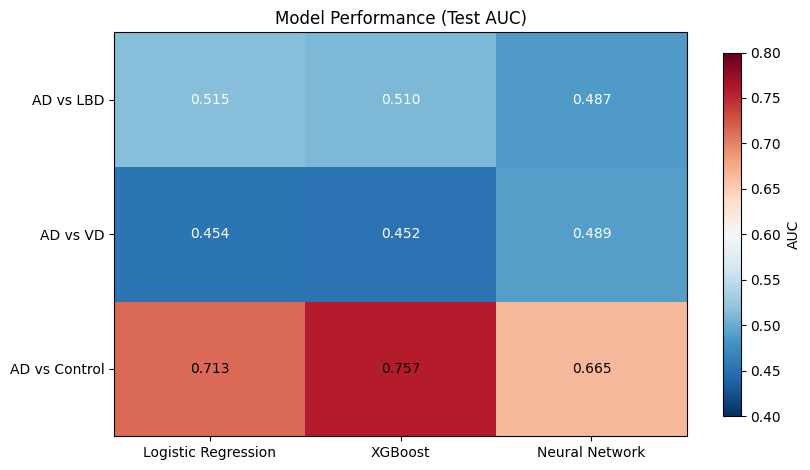


AUC table:
               Logistic Regression  XGBoost  Neural Network
AD vs Control               0.7125   0.7571          0.6646
AD vs VD                    0.4543   0.4518          0.4891
AD vs LBD                   0.5146   0.5105          0.4870


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# AUC values
data = {
    "Logistic Regression": {
        "AD vs Control": 0.7125,
        "AD vs VD":      0.4543,
        "AD vs LBD":     0.5146,
    },
    "XGBoost": {
        "AD vs Control": 0.7571,
        "AD vs VD":      0.4518,
        "AD vs LBD":     0.5105,
    },
    "Neural Network": {
        "AD vs Control": 0.6646,
        "AD vs VD":      0.4891,
        "AD vs LBD":     0.4870,
    },
}

rows = ["AD vs Control", "AD vs VD", "AD vs LBD"]
cols = ["Logistic Regression", "XGBoost", "Neural Network"]
df = pd.DataFrame({c: {r: data[c][r] for r in rows} for c in cols}, index=rows)

# Heatmap (RdBu_r, no lines, x-labels horizontal)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

vmin, vmax = 0.40, 0.80  # adjust if you’d like a different range
im = ax.imshow(
    df.values,
    cmap="RdBu_r",
    origin="lower",
    vmin=vmin, vmax=vmax,
    interpolation="nearest",  # crisp blocks; avoids white seams
    aspect="auto"
)

# Ticks & labels (x labels NOT angled)
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=0, ha="center")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)

# No lines at all between cells (no grid, no minor ticks)
# (imshow doesn't draw edges; we simply avoid adding any gridlines.)

# Title & colorbar
ax.set_title("Model Performance (Test AUC)")
cbar = plt.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("AUC", rotation=90)

# Value annotations
vals = df.values
mid = (vmin + vmax) / 2.0
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        val = vals[i, j]
        txt_color = "black" if val >= mid else "white"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10, color=txt_color)

plt.tight_layout()
plt.savefig("auc_heatmap_rdbu.png", dpi=300, bbox_inches="tight")
plt.savefig("auc_heatmap_rdbu.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Optional: print the table
print("\nAUC table:")
print(df.to_string())



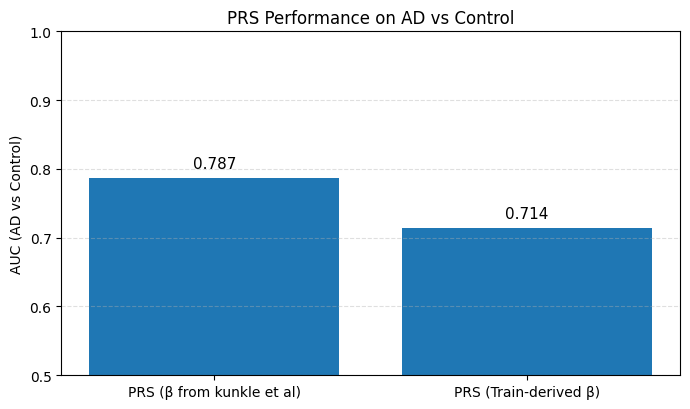

In [3]:
# Bar graph for PRS 
import matplotlib.pyplot as plt

# AUCs for AD vs Control
labels = ["PRS (β from kunkle et al)", "PRS (Train-derived β)"]
aucs   = [0.787, 0.714]

fig, ax = plt.subplots(figsize=(7, 4.2))

# Bars (no custom colors)
x = range(len(labels))
bars = ax.bar(x, aucs)

# Labels & title
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("AUC (AD vs Control)")
ax.set_title("PRS Performance on AD vs Control")

# y-axis limits
ymin = 0.5
ymax = 1
ax.set_ylim(ymin, ymax)

# Grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate values on bars
for i, v in enumerate(aucs):
    ax.text(i, v + (ymax - ymin) * 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("ad_vs_control_prs_bars.png", dpi=300, bbox_inches="tight")
plt.savefig("ad_vs_control_prs_bars.pdf", dpi=300, bbox_inches="tight")
plt.show()


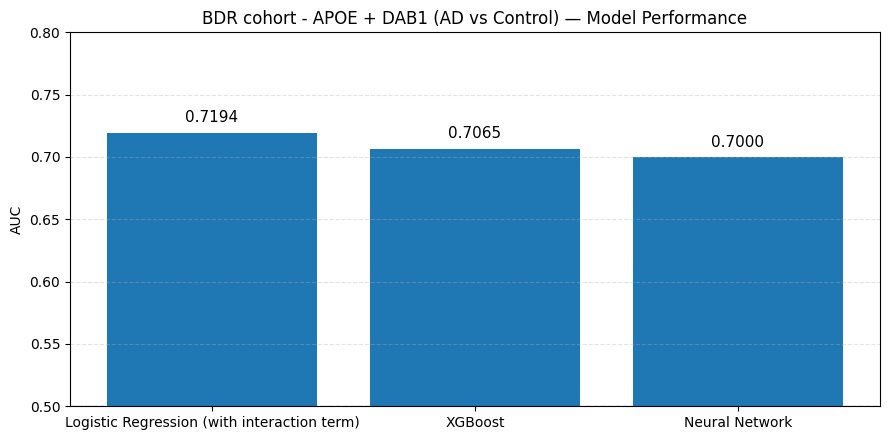

In [15]:
# (AD vs Control) for APOE + DAB1
import matplotlib.pyplot as plt

# AUCs 
labels = [
    "Logistic Regression (with interaction term)",
    "XGBoost",
    "Neural Network"
]
aucs = [0.7194, 0.7065, 0.7000]

fig, ax = plt.subplots(figsize=(9, 4.5))

# Bars
x = range(len(labels))
bars = ax.bar(x, aucs)

# Axes/labels
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("AUC")
ax.set_title("BDR cohort - APOE + DAB1 (AD vs Control) — Model Performance")

# Baseline at random (AUC=0.5)
ax.axhline(0.5, linestyle="--", linewidth=1, alpha=0.6)

# Y axis limits
ymin = 0.5
ymax = 0.8
ax.set_ylim(ymin, ymax)

# Grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.35)

# Annotate values on bars
for i, v in enumerate(aucs):
    ax.text(i, v + (ymax - ymin) * 0.02, f"{v:.4f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("apoe_dab1_ad_vs_control_bars.png", dpi=300, bbox_inches="tight")
plt.savefig("apoe_dab1_ad_vs_control_bars.pdf", dpi=300, bbox_inches="tight")
plt.show()


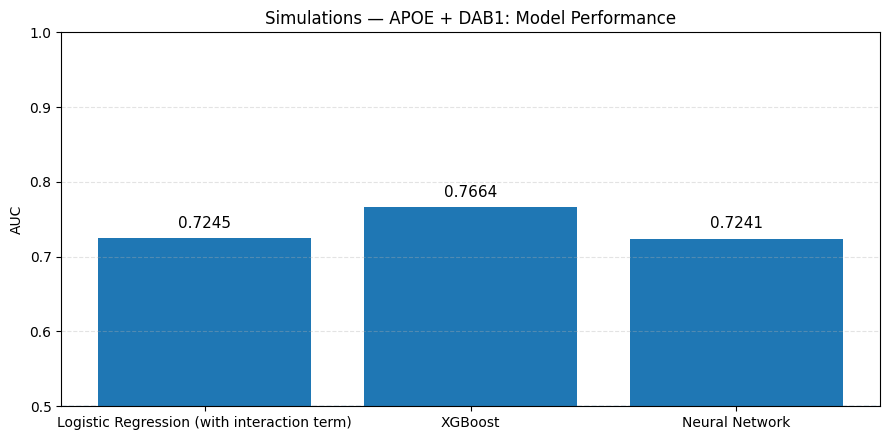

In [14]:
# AUCs from simulations (APOE + DAB1)

import matplotlib.pyplot as plt

labels = [
    "Logistic Regression (with interaction term)",
    "XGBoost",
    "Neural Network"
]
aucs = [0.7245, 0.7664, 0.7241]

fig, ax = plt.subplots(figsize=(9, 4.5))

# Bars
x = range(len(labels))
bars = ax.bar(x, aucs)

# Axes/labels
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("AUC")
ax.set_title("Simulations — APOE + DAB1: Model Performance")

# Baseline at random (AUC = 0.5)
ax.axhline(0.5, linestyle="--", linewidth=1, alpha=0.6)

# Y axis limits
ymin = 0.5
ymax = 1
ax.set_ylim(ymin, ymax)

# Grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.35)

# Annotate values on bars
for i, v in enumerate(aucs):
    ax.text(i, v + (ymax - ymin) * 0.02, f"{v:.4f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("sim_apoe_dab1_bars.png", dpi=300, bbox_inches="tight")
plt.savefig("sim_apoe_dab1_bars.pdf", dpi=300, bbox_inches="tight")
plt.show()
